In [1]:
import os 
from glob import glob
import SimpleITK as sitk
import numpy as np
import datasets.path as path
from segment_anything import sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide
from skimage import transform, segmentation, io
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from utils import min_max_norm_3dimg, NpzDataset
import json
from pre_embeddings import sam_preprocess
from torch.utils.data import DataLoader, Dataset

In [31]:
# training and testing saving dataset path prefix
prefix = './datasets/RAINE_organ_51'
task = 'MRI_LeftKidney_sagittal_all'
# label id
# left kidney: 1,
# right kidney: 2,
# pancreas: 3,
# background: 0,
label_id = 1
# image size
image_size = 256
#SAM MODEL TYPE 
sam_model_type = 'vit_b'
# SAM checkpoint
checkpoint = './checkpoints/SAM/sam_vit_b_01ec64.pth'
# device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [32]:
# load data paths
images = sorted(glob(os.path.join(path.RAINE_ORGAN_IMAGES_51, '*.nii.gz')))
gts = sorted(glob(os.path.join(path.RAINE_ORGAN_MANUAL_GTS_51, '*.nii.gz')))
names = [os.path.basename(image).split('/')[-1] for image in images]
# split data into train, test
np.random.seed(2023)
np.random.shuffle(names)
train_names = sorted(names[:int(len(names)*0.8)]) # 40
test_names = sorted(names[int(len(names)*0.8):]) # 11
# prepare the save path
save_path_tr = os.path.join(prefix, task, 'train')
save_path_ts = os.path.join(prefix, task, 'test')
# save data ti train nad test folder
os.makedirs(save_path_tr, exist_ok=True)
os.makedirs(save_path_ts, exist_ok=True)


In [33]:
for name in train_names:
    img_path = os.path.join(path.RAINE_ORGAN_IMAGES_51, name)
    print('image_name', img_path)
    gt_path = os.path.join(path.RAINE_ORGAN_MANUAL_GTS_51, name)
    # load image and gt
    img = sitk.ReadImage(img_path)
    img_array = sitk.GetArrayFromImage(img)
    gt = sitk.ReadImage(gt_path)
    gt_array = sitk.GetArrayFromImage(gt)
    gt_array = np.uint8(gt_array==label_id)
    # norlize image
    img_norm = min_max_norm_3dimg(img_array) 
    break

image_name /scratch/user/uqxye5/segmentation/ALMRI/datasets/RAINE_organ_51/trainingset_51/sub-10010.FatImaging_W.nii.gz


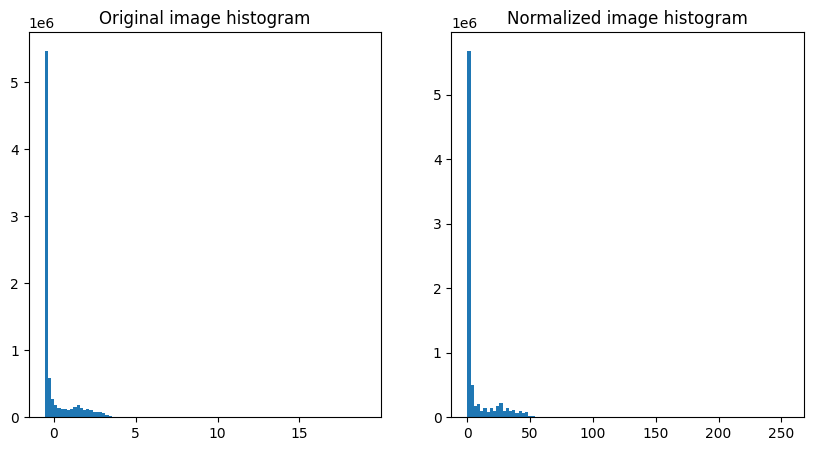

In [26]:
# image intensity distrubution before and after normalization
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(img_array.flatten(), bins=100)
ax[0].set_title('Original image histogram')

ax[1].hist(img_norm.flatten(), bins=100)
ax[1].set_title('Normalized image histogram')

plt.show()

In [27]:
def get_slice(array, index, i):
    x, y, z = array.shape
    if index == x:
        return array[i,:,:]
    elif index == y:
        return array[:,i,:]
    elif index == z:
        return array[:,:,i]

def sam_preprocess(filter, view, img, gt, image_size, sam_model, device):
    """Resize image and ground truth to 256*256, and get the image embedding
    Args:
        img: 3D image
        gt: 3D ground truth
        image_size: image size
        sam_model: sam model
        device: device
    Return:
        img: 2D image list
        gt: 2D ground truth list
        img_embeddings: image embeddings
    """
    imgs = []
    gts = []
    img_embeddings = []
    index = img.shape[view]
    label_index = []
    for i in range(index):
        gt_slice_i = get_slice(gt, index, i)
        gt_slice_i = transform.resize(gt_slice_i, (image_size, image_size), order=0, preserve_range=True, mode='constant', anti_aliasing=True)
        if np.sum(gt_slice_i)>=filter: # select slice containing organ
            img_slice_i = get_slice(img, index, i)
            label_index.append(i)
            # resize img_slice_i to 256x256
            img_slice_i = transform.resize(img_slice_i, (image_size, image_size), order=3, preserve_range=True, mode='constant', anti_aliasing=True)
            # convert to three channels
            img_slice_i = np.uint8(np.repeat(img_slice_i[:,:,None], 3, axis=-1))
            assert len(img_slice_i.shape)==3 and img_slice_i.shape[2]==3, 'image should be 3 channels'
            assert img_slice_i.shape[0]==gt_slice_i.shape[0] and img_slice_i.shape[1]==gt_slice_i.shape[1], 'image and ground truth should have the same size'
            imgs.append(img_slice_i)
            # print('img_slice_i', img_slice_i.shape)
            # assert np.sum(gt_slice_i)>100, 'ground truth should have more than 100 pixels'
            gts.append(gt_slice_i)

            if sam_model is not None:
                sam_transform = ResizeLongestSide(sam_model.image_encoder.img_size)
                resize_img = sam_transform.apply_image(img_slice_i)
                resize_img_tensor = torch.as_tensor(resize_img.transpose(2, 0, 1)).to(device)
                # model input: (1, 3, 1024, 1024)
                input_image = sam_model.preprocess(resize_img_tensor[None,:,:,:]) # (1, 3, 1024, 1024)
                assert input_image.shape == (1, 3, sam_model.image_encoder.img_size, sam_model.image_encoder.img_size), 'input image should be resized to 1024*1024'
                with torch.no_grad():
                    embedding = sam_model.image_encoder(input_image)
                    img_embeddings.append(embedding.cpu().numpy()[0])

    # print('label_index', label_index)
    if sam_model is not None:
        return imgs, gts, img_embeddings, label_index
    else:
        return imgs, gts, label_index

In [34]:
# set up the model
sam_model = sam_model_registry[sam_model_type](checkpoint=checkpoint).to(device)
filter = 0
view = 2
# preprocess the training dataset
# outliers: sub-14870, sub-16880, sub-22770, sub-41810, sub-52220
for name in tqdm(train_names):
    img_path = os.path.join(path.RAINE_ORGAN_IMAGES_51, name)
    gt_path = os.path.join(path.RAINE_ORGAN_MANUAL_GTS_51, name)
    # load image and gt
    img = sitk.ReadImage(img_path)
    img_array = sitk.GetArrayFromImage(img)
    gt = sitk.ReadImage(gt_path)
    gt_array = sitk.GetArrayFromImage(gt)
    gt_array = np.uint8(gt_array==label_id)

    # normalize image
    img_norm = min_max_norm_3dimg(img_array) 

    # preprocess the image and gt for SAM
    imgs, gts, img_embeddings, label_index = sam_preprocess(filter, view, img_norm, gt_array, image_size, sam_model, device)

    # stack the list to array then save to npz file
    if len(imgs)>1:
        imgs = np.stack(imgs, axis=0) # (n, 256, 256, 3)
        gts = np.stack(gts, axis=0) # (n, 256, 256)
        img_embeddings = np.stack(img_embeddings, axis=0) # (n, 1, 256, 64, 64)
        print(name, 'imgs shape', imgs.shape, '\tgts shape', gts.shape, '\timg_embeddings shape', img_embeddings.shape)
        np.savez_compressed(os.path.join(save_path_tr, name.split('.nii.gz')[0]+'.npz'), imgs=imgs, gts=gts, img_embeddings=img_embeddings)
        # save an example image for sanity check
        idx = np.random.randint(0, imgs.shape[0])
        img_idx = imgs[idx,:,:,:]
        gt_idx = gts[idx,:,:]
        bd = segmentation.find_boundaries(gt_idx, mode='inner')
        img_idx[bd, :] = [255, 0, 0]
        io.imsave(save_path_tr + '.png', img_idx, check_contrast=False)
    break


  0%|          | 0/40 [00:00<?, ?it/s]

sub-10010.FatImaging_W.nii.gz imgs shape (288, 256, 256, 3) 	gts shape (288, 256, 256) 	img_embeddings shape (288, 256, 64, 64)


  0%|          | 0/40 [01:12<?, ?it/s]


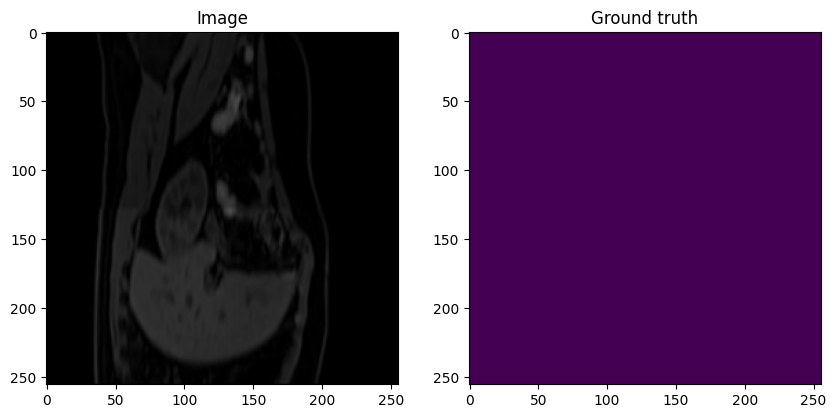

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
index = 102
ax[0].imshow(imgs[index])
ax[0].set_title('Image')
ax[1].imshow(gts[index])
ax[1].set_title('Ground truth')
plt.show()

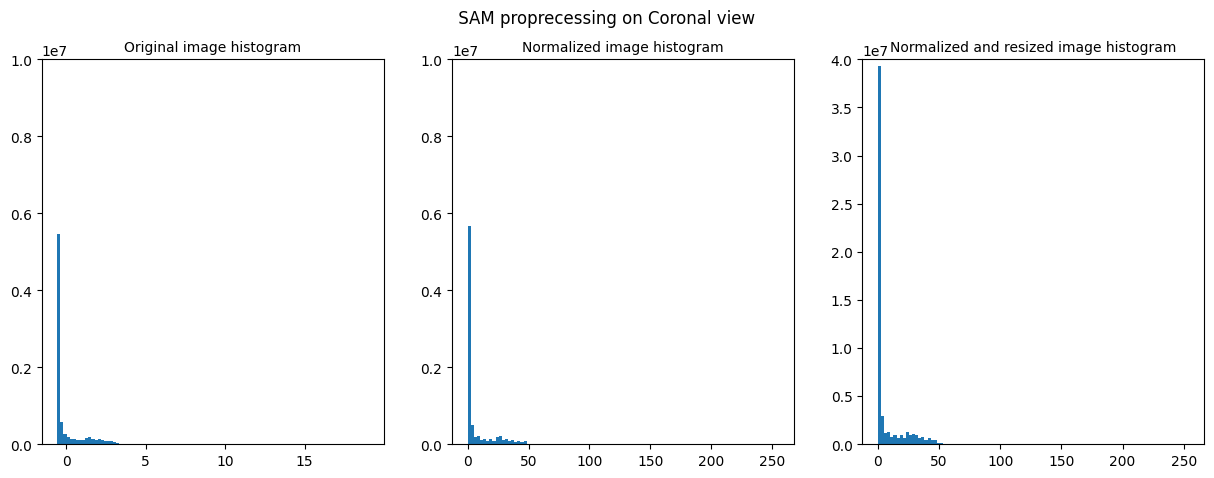

In [38]:
# image intensity distrubution before and after normalization and resize
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].hist(img_array.flatten(), bins=100)
ax[0].set_title('Original image histogram', fontsize=10)
ax[0].set_ylim([0, 1e7])

ax[1].hist(img_norm.flatten(), bins=100)
ax[1].set_title('Normalized image histogram', fontsize=10)
ax[1].set_ylim([0, 1e7])

ax[2].hist(imgs.flatten(), bins=100)
ax[2].set_title('Normalized and resized image histogram', fontsize=10)
ax[2].set_ylim([0, 4e7])

fig.suptitle(' SAM proprecessing on Coronal view')
plt.show()


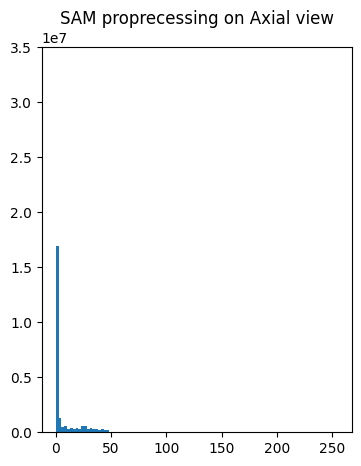

In [40]:
axial_imgs = np.load('datasets/RAINE_organ_51/MRI_LeftKidney_all/train/sub-10010.FatImaging_W.npz')['imgs']
axial_gts = np.load('datasets/RAINE_organ_51/MRI_LeftKidney_all/train/sub-10010.FatImaging_W.npz')['gts']
axial_img_embeddings = np.load('datasets/RAINE_organ_51/MRI_LeftKidney_all/train/sub-10010.FatImaging_W.npz')['img_embeddings']

# image intensity distrubution before and after normalization and resize
plt.figure(figsize=(4,5))
plt.hist(axial_imgs.flatten(), bins=100)
plt.ylim([0, 3.5e7])
plt.title('SAM proprecessing on Axial view')
plt.show()